In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt


In [2]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [3]:
print('타겟변수 : ', data[0,0])
image = data[0, 1:].reshape(28,28)
image.shape

타겟변수 :  5.0


(28, 28)

In [4]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

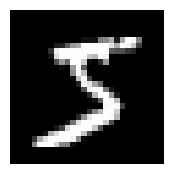

In [5]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [6]:
# 컬러사진 -> 흑백모드로 넘파이배열로 읽기(pyp install)

In [7]:
import cv2
# 사진이미지를 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

<function matplotlib.pyplot.show(close=None, block=None)>

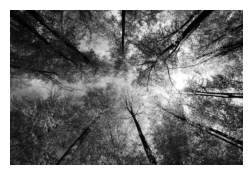

In [8]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show

# 1. 데이터 생서 및 전처리

In [9]:
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [10]:
value, counts = np.unique(y_train, return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [11]:
value, counts = np.unique(y_test, return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

2


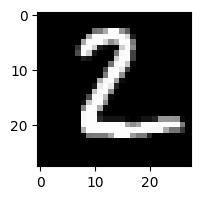

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [12]:
print(y_test[1])
plt.imshow(X_test[1], cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()

In [13]:
# Train 데이터 6만개 => Train(5만개) + val(만개)로 분리
(X_train, y_train),(X_test, y_test) = mnist.load_data() # 6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [14]:
print('학습셋 : ', X_train.shape, y_train.shape)
print('검증셋 : ', X_val.shape, y_val.shape)
print('시험셋 : ', X_test.shape, y_test.shape)

학습셋 :  (50000, 28, 28) (50000,)
검증셋 :  (10000, 28, 28) (10000,)
시험셋 :  (10000, 28, 28) (10000,)


In [15]:
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [16]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [17]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목정: 수업시간중 fit 시간절약)
# idx = random.sample(range(50000), 10)
train_idx = np.random.choice(50000, 700)
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]

In [19]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10))

# 2. 모델 구성
# 3. 학습과정 설정
# 4. 모델 학습

In [21]:
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 1570      
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_3 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


In [30]:
%%time
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=100,
                epochs=200)

Epoch 1/200
7/7 [==============================] - 0s 12ms/step - loss: 1.5863 - accuracy: 0.4343 - val_loss: 1.5411 - val_accuracy: 0.4300
Epoch 2/200
7/7 [==============================] - 0s 9ms/step - loss: 1.5517 - accuracy: 0.4471 - val_loss: 1.5182 - val_accuracy: 0.4200
Epoch 3/200
7/7 [==============================] - 0s 8ms/step - loss: 1.5275 - accuracy: 0.4457 - val_loss: 1.5026 - val_accuracy: 0.4200
Epoch 4/200
7/7 [==============================] - 0s 8ms/step - loss: 1.5083 - accuracy: 0.4571 - val_loss: 1.4926 - val_accuracy: 0.4300
Epoch 5/200
7/7 [==============================] - 0s 9ms/step - loss: 1.4901 - accuracy: 0.4686 - val_loss: 1.4850 - val_accuracy: 0.4267
Epoch 6/200
7/7 [==============================] - 0s 10ms/step - loss: 1.4768 - accuracy: 0.4671 - val_loss: 1.4773 - val_accuracy: 0.4267
Epoch 7/200
7/7 [==============================] - 0s 8ms/step - loss: 1.4650 - accuracy: 0.4657 - val_loss: 1.4726 - val_accuracy: 0.4200
Epoch 8/200
7/7 [========

7/7 [==============================] - 0s 7ms/step - loss: 1.1417 - accuracy: 0.6029 - val_loss: 1.4245 - val_accuracy: 0.4767
Epoch 118/200
7/7 [==============================] - 0s 8ms/step - loss: 1.1401 - accuracy: 0.6029 - val_loss: 1.4232 - val_accuracy: 0.4833
Epoch 119/200
7/7 [==============================] - 0s 8ms/step - loss: 1.1386 - accuracy: 0.6043 - val_loss: 1.4233 - val_accuracy: 0.4833
Epoch 120/200
7/7 [==============================] - 0s 8ms/step - loss: 1.1385 - accuracy: 0.6014 - val_loss: 1.4256 - val_accuracy: 0.4700
Epoch 121/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1357 - accuracy: 0.6014 - val_loss: 1.4238 - val_accuracy: 0.4833
Epoch 122/200
7/7 [==============================] - 0s 9ms/step - loss: 1.1346 - accuracy: 0.6000 - val_loss: 1.4251 - val_accuracy: 0.4733
Epoch 123/200
7/7 [==============================] - 0s 8ms/step - loss: 1.1329 - accuracy: 0.6029 - val_loss: 1.4243 - val_accuracy: 0.4800
Epoch 124/200
7/7 [========

# 모델평가하기

In [23]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

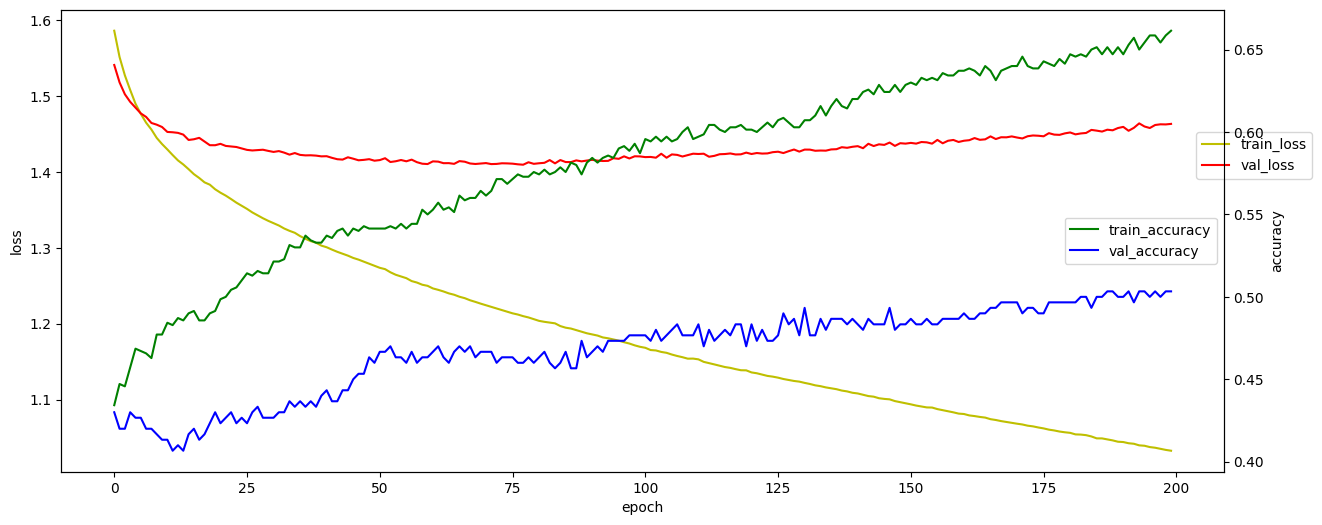

In [31]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()

In [28]:
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

loss :  1.6203160285949707
accuracy :  0.4465999901294708


# 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validauion data추가, 활성화함수를 relu계열, than, Dropout추가, 배치정규화, L2정규화(규제)...)
- epoch 조정
- optimizer 변경

In [40]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
# val_idx   = np.random.choice(10000, 300)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# val_X   = val_X[val_idx]
# val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784->1024->512->128->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=1024))
model.add(BatchNormalization()) # 1024개 출력층을 배치 정규화
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dropout(0.2))

model.add(Dense(units=512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(units=10, activation='softmax'))
model.summary()
# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=30, 
                verbose=2
                )

(50000, 784) (50000, 10) (10000, 784) (10000, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_20 (Dense)            (None, 1024)              803840    
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 1024)              0         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_21 (Dense)            (None, 512)               524800    
                                                                 
 batch_normalization_1 (Batc  (None, 512)      

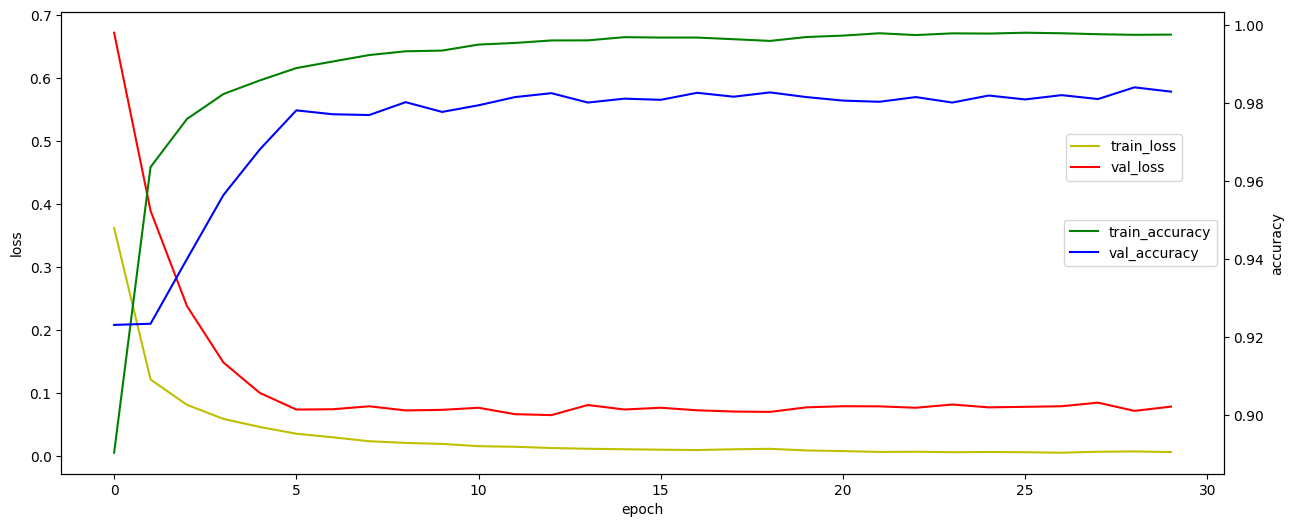

loss : 0.08169867843389511
accuracy : 0.9801999926567078


In [41]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

In [42]:
# 교차표
y_test # 실제값 
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1) == y_test)

True

In [43]:
y_hat = model.predict(test_X).argmax(axis=1) # 예측값
y_hat = np.argmax(model.predict(test_X), axis=1)
y_hat

313/313 [==============================] - 2s 5ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [44]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,973,1,0,0,0,1,2,1,2,0
1,0,1129,1,0,0,0,2,0,3,0
2,4,1,1012,2,1,0,0,4,8,0
3,0,0,5,987,0,3,0,3,7,5
4,2,0,6,1,953,0,2,2,1,15
5,3,0,1,10,1,860,6,1,6,4
6,5,2,1,1,1,1,942,0,5,0
7,3,5,10,1,0,0,0,1002,3,4
8,2,1,2,2,2,1,0,1,959,4


In [45]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[ 973,    1,    0,    0,    0,    1,    2,    1,    2,    0],
       [   0, 1129,    1,    0,    0,    0,    2,    0,    3,    0],
       [   4,    1, 1012,    2,    1,    0,    0,    4,    8,    0],
       [   0,    0,    5,  987,    0,    3,    0,    3,    7,    5],
       [   2,    0,    6,    1,  953,    0,    2,    2,    1,   15],
       [   3,    0,    1,   10,    1,  860,    6,    1,    6,    4],
       [   5,    2,    1,    1,    1,    1,  942,    0,    5,    0],
       [   3,    5,   10,    1,    0,    0,    0, 1002,    3,    4],
       [   2,    1,    2,    2,    2,    1,    0,    1,  959,    4],
       [   3,    4,    1,    4,    7,    1,    1,    2,    1,  985]],
      dtype=int64)

In [46]:
# 틀린갯수
accuracy = loss_metrics[1]
10000 - 10000 * accuracy

198.00007343292236

# ※ 콜백함수 1: 로그출력

In [5]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [8]:
%%time
# 특정 에포크마다 로그출력을 하도록 제한 callback 클래스
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}):
        '1 epoch 수행 후 자동 실행되는 함수'
        self.epoch += 1
        if self.epoch%10==0: # 10에포크마다 로그 출력
            print('epoch:{}, loss:{:.4f}, add:{:.4f}, val_loss:{:.4f}, val_acc:{:.4f}'\
                  .format(self.epoch,
                          logs.get('loss', '-'),
                          logs.get('accuracy', '-'),
                          logs.get('val_loss', '-'),
                          logs.get('val_accuracy', '-'),
                          )
                 )
            
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0

# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)

# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)

# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표

# 모델 학습
customHistory = CustomHistory()
print(customHistory.epoch)
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=0,
                callbacks=[customHistory]
                )

(700, 784) (700, 10) (300, 784) (300, 10) (10000, 784) (10000, 10)
0
epoch:10, loss:2.2735, add:0.1800, val_loss:2.2597, val_acc:0.1500
epoch:20, loss:2.2070, add:0.1843, val_loss:2.1911, val_acc:0.1533
epoch:30, loss:2.1458, add:0.2143, val_loss:2.1323, val_acc:0.1833
epoch:40, loss:2.0971, add:0.2357, val_loss:2.0880, val_acc:0.1967
epoch:50, loss:2.0573, add:0.2500, val_loss:2.0523, val_acc:0.2033
epoch:60, loss:2.0231, add:0.2600, val_loss:2.0216, val_acc:0.2200
epoch:70, loss:1.9921, add:0.2771, val_loss:1.9941, val_acc:0.2233
epoch:80, loss:1.9636, add:0.2943, val_loss:1.9691, val_acc:0.2300
epoch:90, loss:1.9372, add:0.3029, val_loss:1.9460, val_acc:0.2533
epoch:100, loss:1.9126, add:0.3014, val_loss:1.9246, val_acc:0.2500
epoch:110, loss:1.8896, add:0.3043, val_loss:1.9043, val_acc:0.2533
epoch:120, loss:1.8678, add:0.3057, val_loss:1.8850, val_acc:0.2500
epoch:130, loss:1.8472, add:0.3071, val_loss:1.8670, val_acc:0.2633
epoch:140, loss:1.8276, add:0.3057, val_loss:1.8503, val

# ※ 콜백함수2 : EarlyStopping
- val_loss 값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기종료
- val_accuracy 값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [10]:
%%time
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표

# 모델 학습
earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping]
                )

Epoch 1/200
1/1 - 1s - loss: 2.3251 - accuracy: 0.0614 - val_loss: 2.3125 - val_accuracy: 0.1267 - 689ms/epoch - 689ms/step
Epoch 2/200
1/1 - 0s - loss: 2.3193 - accuracy: 0.1071 - val_loss: 2.3085 - val_accuracy: 0.1233 - 47ms/epoch - 47ms/step
Epoch 3/200
1/1 - 0s - loss: 2.3146 - accuracy: 0.1057 - val_loss: 2.3054 - val_accuracy: 0.1200 - 39ms/epoch - 39ms/step
Epoch 4/200
1/1 - 0s - loss: 2.3110 - accuracy: 0.1086 - val_loss: 2.3031 - val_accuracy: 0.1233 - 27ms/epoch - 27ms/step
Epoch 5/200
1/1 - 0s - loss: 2.3081 - accuracy: 0.1071 - val_loss: 2.3012 - val_accuracy: 0.1267 - 32ms/epoch - 32ms/step
Epoch 6/200
1/1 - 0s - loss: 2.3055 - accuracy: 0.1114 - val_loss: 2.2998 - val_accuracy: 0.1233 - 31ms/epoch - 31ms/step
Epoch 7/200
1/1 - 0s - loss: 2.3032 - accuracy: 0.1157 - val_loss: 2.2984 - val_accuracy: 0.1267 - 28ms/epoch - 28ms/step
Epoch 8/200
1/1 - 0s - loss: 2.3013 - accuracy: 0.1186 - val_loss: 2.2968 - val_accuracy: 0.1300 - 32ms/epoch - 32ms/step
Epoch 9/200
1/1 - 0s -

Epoch 68/200
1/1 - 0s - loss: 1.9952 - accuracy: 0.2114 - val_loss: 1.9537 - val_accuracy: 0.2400 - 28ms/epoch - 28ms/step
Epoch 69/200
1/1 - 0s - loss: 1.9921 - accuracy: 0.2143 - val_loss: 1.9507 - val_accuracy: 0.2400 - 31ms/epoch - 31ms/step
Epoch 70/200
1/1 - 0s - loss: 1.9890 - accuracy: 0.2143 - val_loss: 1.9478 - val_accuracy: 0.2400 - 31ms/epoch - 31ms/step
Epoch 71/200
1/1 - 0s - loss: 1.9860 - accuracy: 0.2143 - val_loss: 1.9448 - val_accuracy: 0.2400 - 28ms/epoch - 28ms/step
Epoch 72/200
1/1 - 0s - loss: 1.9830 - accuracy: 0.2143 - val_loss: 1.9419 - val_accuracy: 0.2467 - 26ms/epoch - 26ms/step
Epoch 73/200
1/1 - 0s - loss: 1.9800 - accuracy: 0.2143 - val_loss: 1.9391 - val_accuracy: 0.2500 - 27ms/epoch - 27ms/step
Epoch 74/200
1/1 - 0s - loss: 1.9770 - accuracy: 0.2157 - val_loss: 1.9362 - val_accuracy: 0.2500 - 38ms/epoch - 38ms/step
Epoch 75/200
1/1 - 0s - loss: 1.9741 - accuracy: 0.2157 - val_loss: 1.9334 - val_accuracy: 0.2533 - 28ms/epoch - 28ms/step
Epoch 76/200
1/1

Epoch 135/200
1/1 - 0s - loss: 1.8133 - accuracy: 0.2814 - val_loss: 1.7856 - val_accuracy: 0.2800 - 37ms/epoch - 37ms/step
Epoch 136/200
1/1 - 0s - loss: 1.8108 - accuracy: 0.2814 - val_loss: 1.7833 - val_accuracy: 0.2833 - 30ms/epoch - 30ms/step
Epoch 137/200
1/1 - 0s - loss: 1.8083 - accuracy: 0.2814 - val_loss: 1.7811 - val_accuracy: 0.2833 - 28ms/epoch - 28ms/step
Epoch 138/200
1/1 - 0s - loss: 1.8058 - accuracy: 0.2814 - val_loss: 1.7789 - val_accuracy: 0.2833 - 30ms/epoch - 30ms/step
Epoch 139/200
1/1 - 0s - loss: 1.8033 - accuracy: 0.2814 - val_loss: 1.7767 - val_accuracy: 0.2833 - 27ms/epoch - 27ms/step
Epoch 140/200
1/1 - 0s - loss: 1.8008 - accuracy: 0.2829 - val_loss: 1.7745 - val_accuracy: 0.2800 - 28ms/epoch - 28ms/step
Epoch 141/200
1/1 - 0s - loss: 1.7984 - accuracy: 0.2843 - val_loss: 1.7723 - val_accuracy: 0.2800 - 27ms/epoch - 27ms/step
Epoch 142/200
1/1 - 0s - loss: 1.7959 - accuracy: 0.2857 - val_loss: 1.7701 - val_accuracy: 0.2767 - 25ms/epoch - 25ms/step
Epoch 14

# ※ 콜백함수3 : ModelCheckpoint
- epoch마다 val_acc(val_loss, loss, acc)값이 좋을 떄마다 모델을 자동 저장하는 콜백

In [11]:
%%time
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 자동 저장 콜백
import os
model_save_folder = 'model07/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist_{epoch:03d}_val{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(filepath=file,
                             monitor='val_accuracy', # 모니터할 지표(기본값은 val_loss)
                             save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                             mode = 'max', # 값이 커질수록 저장
                             verbose=1
                             )

earlyStopping = EarlyStopping(monitor='val_accuracy', patience=10) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping, checkpoint]
                )

Epoch 1/200

Epoch 1: val_accuracy improved from -inf to 0.10667, saving model to model07\mnist_001_val0.1067.h5
1/1 - 1s - loss: 2.3120 - accuracy: 0.0871 - val_loss: 2.2986 - val_accuracy: 0.1067 - 681ms/epoch - 681ms/step
Epoch 2/200

Epoch 2: val_accuracy improved from 0.10667 to 0.13333, saving model to model07\mnist_002_val0.1333.h5
1/1 - 0s - loss: 2.3040 - accuracy: 0.0971 - val_loss: 2.2927 - val_accuracy: 0.1333 - 54ms/epoch - 54ms/step
Epoch 3/200

Epoch 3: val_accuracy improved from 0.13333 to 0.14333, saving model to model07\mnist_003_val0.1433.h5
1/1 - 0s - loss: 2.2975 - accuracy: 0.1243 - val_loss: 2.2875 - val_accuracy: 0.1433 - 59ms/epoch - 59ms/step
Epoch 4/200

Epoch 4: val_accuracy improved from 0.14333 to 0.15000, saving model to model07\mnist_004_val0.1500.h5
1/1 - 0s - loss: 2.2918 - accuracy: 0.1414 - val_loss: 2.2829 - val_accuracy: 0.1500 - 49ms/epoch - 49ms/step
Epoch 5/200

Epoch 5: val_accuracy did not improve from 0.15000
1/1 - 0s - loss: 2.2869 - accurac

In [13]:
# 최종 학습 모델
model.evaluate(test_X, test_Y)

313/313 [==============================] - 1s 2ms/step - loss: 2.0970 - accuracy: 0.2883


[2.097017526626587, 0.2883000075817108]

In [15]:
# 저장된 모델 중 최선의 모델
model2 = load_model('model07/mnist_030_val0.3000.h5')
model2.evaluate(test_X, test_Y)

313/313 [==============================] - 1s 2ms/step - loss: 2.1519 - accuracy: 0.2758


[2.1519176959991455, 0.2757999897003174]

# ※ 콜백함수 4 : ReduceLROnPlateau
- 성능이 정체될 때 학습률(learning_rate)를 낮춰서 더 세밀하게 최적점을 찾도록 도와주는 콜백

In [16]:
%%time
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 성능 정체시 학습률 낮추는 콜백
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',
                              patience=2,
                              factor=0.5,
                              min_lr=1e-6)


earlyStopping = EarlyStopping(monitor='val_accuracy', patience=10) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping, reduce_lr]
                )

Epoch 1/200
1/1 - 1s - loss: 2.2884 - accuracy: 0.1371 - val_loss: 2.2893 - val_accuracy: 0.1533 - lr: 0.0010 - 591ms/epoch - 591ms/step
Epoch 2/200
1/1 - 0s - loss: 2.2829 - accuracy: 0.1386 - val_loss: 2.2837 - val_accuracy: 0.1433 - lr: 0.0010 - 34ms/epoch - 34ms/step
Epoch 3/200
1/1 - 0s - loss: 2.2775 - accuracy: 0.1443 - val_loss: 2.2786 - val_accuracy: 0.1400 - lr: 0.0010 - 39ms/epoch - 39ms/step
Epoch 4/200
1/1 - 0s - loss: 2.2723 - accuracy: 0.1443 - val_loss: 2.2762 - val_accuracy: 0.1400 - lr: 5.0000e-04 - 44ms/epoch - 44ms/step
Epoch 5/200
1/1 - 0s - loss: 2.2698 - accuracy: 0.1386 - val_loss: 2.2739 - val_accuracy: 0.1433 - lr: 5.0000e-04 - 34ms/epoch - 34ms/step
Epoch 6/200
1/1 - 0s - loss: 2.2674 - accuracy: 0.1386 - val_loss: 2.2728 - val_accuracy: 0.1433 - lr: 2.5000e-04 - 32ms/epoch - 32ms/step
Epoch 7/200
1/1 - 0s - loss: 2.2661 - accuracy: 0.1357 - val_loss: 2.2717 - val_accuracy: 0.1433 - lr: 2.5000e-04 - 31ms/epoch - 31ms/step
Epoch 8/200
1/1 - 0s - loss: 2.2649 -